In [300]:
from astroquery.mast import Catalogs

catalog_data = Catalogs.query_object(
    "TIC 1139218134",
    radius=0.001,
    catalog="TIC"
)

print(catalog_data["Teff"])

 Teff 
------
7072.0
7072.0
7325.0


In [299]:
from astroquery.mast import Catalogs
import numpy as np

results = Catalogs.query_object(
    "TIC 816058534",
    catalog="TIC"
)

if len(results) == 0:
    raise ValueError("No TIC matches found.")

# Keep only rows with finite temperatures
mask = np.isfinite(results["Teff"])
results_valid = results[mask]

if len(results_valid) == 0:
    raise ValueError("No TIC matches with valid Teff found.")

# Select closest remaining match
best = results_valid[np.argmin(results_valid["dstArcSec"])]

print("TIC ID:", best["ID"])
print("Teff:", best["Teff"])
print("Separation:", best["dstArcSec"])

TIC ID: 30051422
Teff: 4629.0
Separation: 27.106734546873238


In [45]:
from astroquery.mast import Catalogs

tic = Catalogs.query_criteria(
    catalog="TIC",
    ID=339812943
)

print(tic["mass"])

mass
----
 nan


In [365]:
import lightkurve as lk

search_result = lk.search_lightcurve("TIC 1139218134")
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 39,2021,QLP,600,1139218134,0.0
1,TESS Sector 65,2023,QLP,200,1139218134,0.0
2,TESS Sector 12,2019,GSFC-ELEANOR-LITE,1800,1139218134,0.0


# HR Diagram

In [2]:
def send_radial_gaia_query(query_size=1000000, distance=200, **kwargs):
    """
    Sends an archive query for d < 200 pc, with additional filters taken from
    Gaia Data Release 2: Observational Hertzsprung-Russell diagrams (Sect. 2.1)
    Gaia Collaboration, Babusiaux et al. (2018)
    (https://doi.org/10.1051/0004-6361/201832843)

    NOTE: 10000000 is a maximum query size (~76 MB / column)

    Additional keyword arguments are passed to TapPlus.launch_job_async method.
    """
    from astroquery.utils.tap.core import TapPlus

    gaia = TapPlus(url="http://gea.esac.esa.int/tap-server/tap")

    job = gaia.launch_job_async("select top {}".format(query_size)+
                #" lum_val, teff_val,"
                #" ra, dec, parallax,"
                " bp_rp, phot_g_mean_mag+5*log10(parallax)-10 as mg"
         " from gaiadr2.gaia_source"
         " where parallax_over_error > 10"
         " and visibility_periods_used > 8"
         " and phot_g_mean_flux_over_error > 50"
         " and phot_bp_mean_flux_over_error > 20"
         " and phot_rp_mean_flux_over_error > 20"
         " and phot_bp_rp_excess_factor <"
            " 1.3+0.06*power(phot_bp_mean_mag-phot_rp_mean_mag,2)"
         " and phot_bp_rp_excess_factor >"
            " 1.0+0.015*power(phot_bp_mean_mag-phot_rp_mean_mag,2)"
         " and astrometric_chi2_al/(astrometric_n_good_obs_al-5)<"
            "1.44*greatest(1,exp(-0.4*(phot_g_mean_mag-19.5)))"
         +" and 1000/parallax <= {}".format(distance), **kwargs)

    return job

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from astroquery.gaia import Gaia

filename = "gaia-hrd-dr2-200pc.csv"

query = """
SELECT TOP 10000000
    bp_rp,
    phot_g_mean_mag + 5 * LOG10(parallax) - 10 AS mg
FROM gaiadr2.gaia_source
WHERE parallax_over_error > 10
  AND visibility_periods_used > 8
  AND phot_g_mean_flux_over_error > 50
  AND phot_bp_mean_flux_over_error > 20
  AND phot_rp_mean_flux_over_error > 20
  AND phot_bp_rp_excess_factor <
      1.3 + 0.06 * POWER(phot_bp_mean_mag - phot_rp_mean_mag, 2)
  AND phot_bp_rp_excess_factor >
      1.0 + 0.015 * POWER(phot_bp_mean_mag - phot_rp_mean_mag, 2)
  AND astrometric_chi2_al / (astrometric_n_good_obs_al - 5) <
      1.44 * GREATEST(1, EXP(-0.4 * (phot_g_mean_mag - 19.5)))
  AND 1000 / parallax <= 200
"""

try:
    gaiarec = np.genfromtxt(
        filename,
        delimiter=",",
        names=True,
        dtype=None,
        encoding="utf-8",
    )
    bp_rp = gaiarec["bp_rp"]
    mg = gaiarec["mg"]

except OSError:
    job = Gaia.launch_job_async(
        query,
        dump_to_file=True,
        output_file=filename,
        output_format="csv",
    )
    r = job.get_results()
    bp_rp = np.array(r["bp_rp"])
    mg = np.array(r["mg"])

Due to scheduled ESAC network maintenance activities, the Archive may suffer short-time disconnections from Monday, 29 June 2026 at 18:00 CEST until Tuesday, 30 June 2026 at 00:00 CEST. We apologize for the inconvenience.


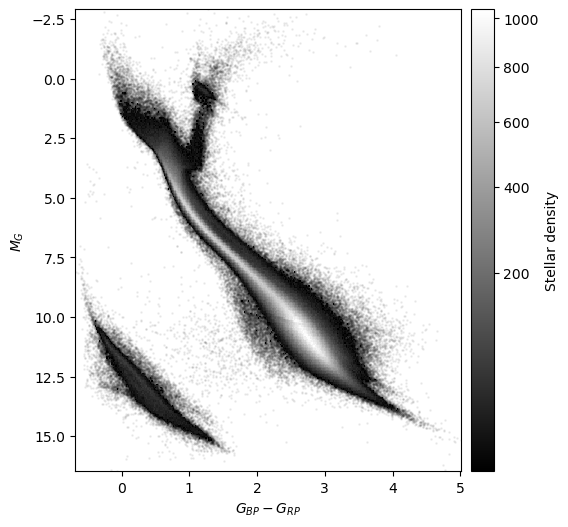

In [2]:
plt.rcParams["text.usetex"] = False

fig, ax = plt.subplots(figsize=(6, 6))

h = ax.hist2d(
    bp_rp,
    mg,
    bins=300,
    cmin=10,
    norm=colors.PowerNorm(0.5),
    zorder=0.5,
    cmap="gray",
)

ax.scatter(bp_rp, mg, alpha=0.05, s=1, color="k", zorder=0)

ax.invert_yaxis()
cb = fig.colorbar(h[3], ax=ax, pad=0.02)

ax.set_xlabel(r"$G_{BP} - G_{RP}$")
ax.set_ylabel(r"$M_G$")
cb.set_label("Stellar density")

plt.show()

In [3]:
import matplotlib as mpl

mpl.rcParams['text.usetex'] = False

In [13]:
import os
import numpy as np

filename = "gaia-hrd-dr2-200pc.csv"

print("CSV exists?", os.path.exists(filename))
if os.path.exists(filename):
    os.remove(filename)
    print("Deleted old CSV")

CSV exists? True
Deleted old CSV


In [21]:
import matplotlib.pyplot as plt
import numpy as np

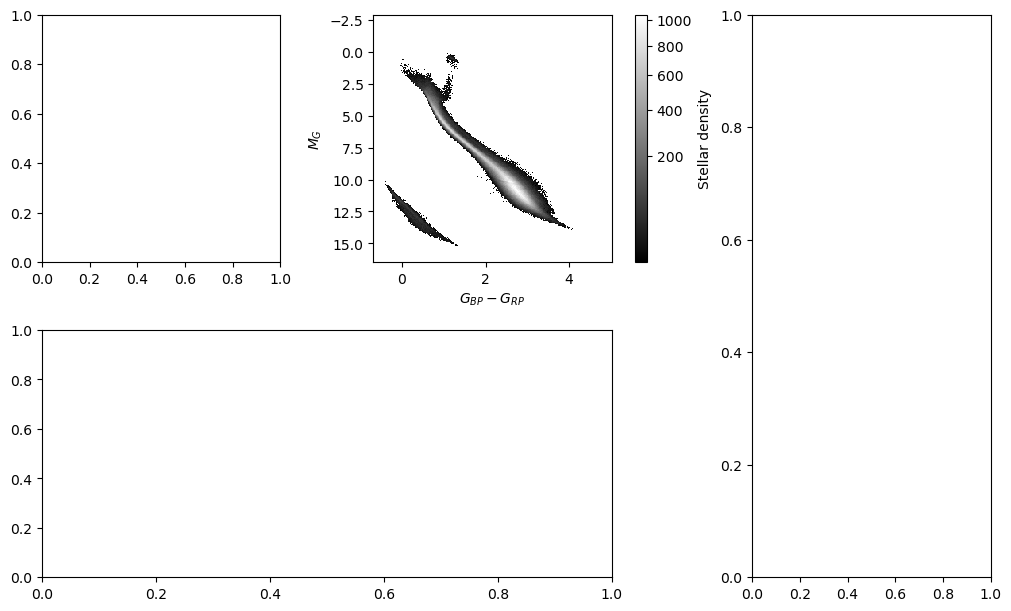

In [34]:
fig = plt.figure(layout="constrained", figsize=(10, 6))
axd = fig.subplot_mosaic(
    """
    ABD
    CCD
    """
)

h = axd["B"].hist2d(
    bp_rp,
    mg,
    bins=300,
    cmin=10,
    norm=colors.PowerNorm(0.5),
    cmap="gray",
)
axd["B"].invert_yaxis()
axd["B"].set_xlabel(r"$G_{BP} - G_{RP}$")
axd["B"].set_ylabel(r"$M_G$")

cbar = fig.colorbar(h[3], ax=axd["B"])
cbar.set_label("Stellar density")

# Updated semantic plots

In [4]:
from astroquery.vizier import Vizier
import numpy as np
import lightkurve_utils as utils
import matplotlib.pyplot as plt
from matplotlib import colors

Vizier.ROW_LIMIT = 10

result = Vizier.query_object(
    "DM Tau",
    catalog="I/355/gaiadr3"
)

print(result.keys())      # see available tables
tab = result[0]           # first table
print(tab.colnames)       # see available columns

print(tab["BP-RP"])

['I/355/gaiadr3']
['RA_ICRS', 'DE_ICRS', 'Source', 'e_RA_ICRS', 'e_DE_ICRS', 'Plx', 'e_Plx', 'PM', 'pmRA', 'e_pmRA', 'pmDE', 'e_pmDE', 'RUWE', 'FG', 'e_FG', 'Gmag', 'FBP', 'e_FBP', 'BPmag', 'FRP', 'e_FRP', 'RPmag', 'BP-RP', 'RV', 'e_RV', 'Vbroad', 'GRVSmag', 'QSO', 'Gal', 'NSS', 'XPcont', 'XPsamp', 'RVS', 'EpochPh', 'EpochRV', 'MCMCGSP', 'MCMCMSC', 'And', 'Teff', 'logg', '[Fe/H]', 'Dist', 'A0', 'HIP', 'PS1', 'SDSS13', 'SKYM2', 'TYC2', 'URAT1', 'AllWISE', 'APASS9', 'GSC23', 'RAVE5', '2MASS', 'RAVE6', 'RAJ2000', 'DEJ2000']
  BP-RP  
   mag   
---------
 1.624229
 1.855946
       --
 1.456764
 1.635433
 1.666710
 2.124437
 2.570314
 1.833874
 1.412151


/Users/shanekomeiji/miniforge3/envs/AstronomicalData/lib/python3.14/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [3]:
from astroquery.vizier import Vizier

v = Vizier(
    columns=["Source", "_r", "Plx", "Gmag", "BPmag", "RPmag", "BP-RP", "RUWE"],
    row_limit=10
)

result = v.query_object("DM Tau", catalog="I/355/gaiadr3")

tab = result[0]
tab = tab[tab["Plx"] > 0]
tab.sort("_r")   # closest valid Gaia source

star = tab[0]

print("Source:", star["Source"])
print("BP-RP:", star["BP-RP"])
print("Gmag:", star["Gmag"])
print("Plx:", star["Plx"])

Source: 3314280954990186496
BP-RP: 1.66671
Gmag: 20.429253
Plx: 0.2858


## Run a low-pass filter over the data

```python
axd["D"].plot(
    trend_lc.time.value,
    trend_lc.flux.value,
    linewidth=2,
    label="Large-scale trend"
)

axd["D"].set_title("Large-Scale Trend")
```

## Compare sectors

SearchResult containing 1 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 15 2019    QLP    1800   189286260      0.0
SearchResult containing 1 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 15 2019    QLP    1800   189286260      0.0


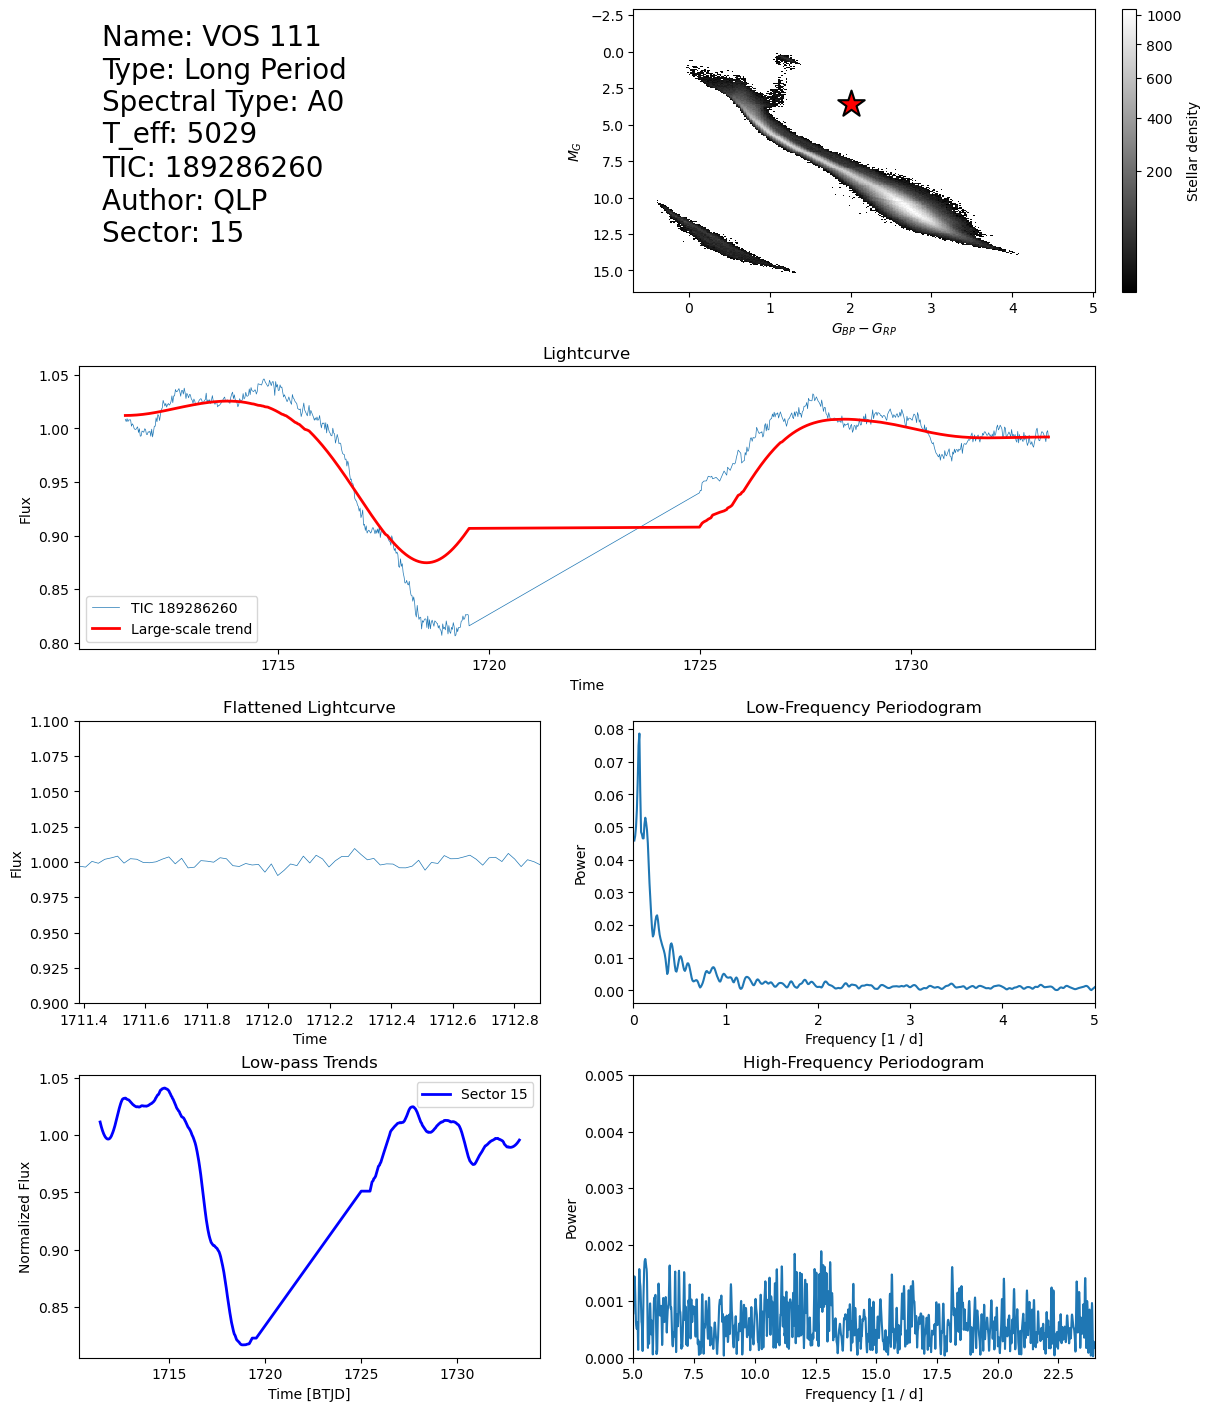

In [208]:
# from pathlib import Path
from scipy.ndimage import gaussian_filter1d

fig = plt.figure(layout="constrained", figsize=(12, 14))
axd = fig.subplot_mosaic(
    """
    FG
    AA
    BC
    DE
    """
)

# Information box
axd["F"].axis("off")

info = (
    "Name: VOS 111\n"
    "Type: Long Period\n"
    "Spectral Type: A0\n"
    "T_eff: 5029\n"
    "TIC: 189286260\n"
    "Author: QLP\n"
    "Sector: 15\n"
)

axd["F"].text(
    0.05, 0.95,
    info,
    transform=axd["F"].transAxes,
    va="top",
    fontsize=20,
)

# HR Diagram
star_bp_rp = 2.003164
plx = 0.6961
gmag = 14.365152
distance_pc = 1000.0 / plx
star_mg = gmag + 5 - 5*np.log10(distance_pc)

h = axd["G"].hist2d(
    bp_rp,
    mg,
    bins=300,
    cmin=10,
    norm=colors.PowerNorm(0.5),
    cmap="gray",
)
axd["G"].invert_yaxis()
axd["G"].set_xlabel(r"$G_{BP} - G_{RP}$")
axd["G"].set_ylabel(r"$M_G$")

axd["G"].scatter(
    star_bp_rp,
    star_mg,
    marker="*",
    s=400,
    color="red",
    edgecolors="black",
    linewidths=1.5,
    zorder=100,
    label="GW Lup",
)

cbar = fig.colorbar(h[3], ax=axd["G"])
cbar.set_label("Stellar density")

# Lightcurve
sectors = [15]

lc, pg = utils.get_lightcurve_periodogram(
    "TIC 189286260",
    author="QLP",
    sector=sectors[0]
)

t = lc.time.value
f = lc.flux.value

mask = np.isfinite(t) & np.isfinite(f)
t = t[mask]
f = f[mask]

# Sort by time
idx = np.argsort(t)
t = t[idx]
f = f[idx]

# Larger sigma = smoother curve
f_smooth = gaussian_filter1d(f, sigma=50)

lc.plot(ax=axd["A"])
axd["A"].set_xlabel("Time")
axd["A"].set_ylabel("Flux")
axd["A"].set_title("Lightcurve")

axd["A"].plot(
    t,
    f_smooth,
    linewidth=2,
    color="red",
    label="Large-scale trend"
)
axd["A"].legend()

# Flattened lightcurve
time = lc.time.value
flat_lc = lc.flatten(window_length=51)
flat_lc.plot(ax=axd["B"])
axd["B"].set_xlabel("Time")
axd["B"].set_ylabel("Flux")
axd["B"].set_title("Flattened Lightcurve")
axd["B"].set_xlim(time.min(), time.min() + 1.5)
axd["B"].set_ylim(0.9, 1.1)
axd["B"].get_legend().remove()

# Periodogram for low frequency
axd["C"].plot(pg.frequency.value, pg.power.value)
axd["C"].set_xlabel(f"Frequency [{pg.frequency.unit}]")
axd["C"].set_ylabel("Power")
axd["C"].set_xlim(0, 5)
#axd["C"].set_ylim(0, 0.0003)
axd["C"].set_title("Low-Frequency Periodogram")

# Periodogram for high frequency
axd["E"].plot(pg.frequency.value, pg.power.value)
axd["E"].set_xlabel(f"Frequency [{pg.frequency.unit}]")
axd["E"].set_ylabel("Power")
axd["E"].set_xlim(5, 24)
axd["E"].set_ylim(0, 0.005)
axd["E"].set_title("High-Frequency Periodogram")

# Flattened lightcurve
sector_colors = {
    15: "blue",
    83: "red",
    31: "green",
}

for sector in sectors:
    lc, pg = utils.get_lightcurve_periodogram(
        "TIC 189286260",
        author="QLP",
        sector=sector
    )

    lc = lc.remove_nans().normalize()

    flat_lc, trend_lc = lc.flatten(
        window_length=51,
        return_trend=True
    )

    axd["D"].plot(
        trend_lc.time.value,
        trend_lc.flux.value,
        linewidth=2,
        color=sector_colors[sector],
        label=f"Sector {sector}"
    )

axd["D"].set_xlabel("Time [BTJD]")
axd["D"].set_ylabel("Normalized Flux")
axd["D"].set_title("Low-pass Trends")
axd["D"].legend()

outdir = Path("figures/Cody/VOS 111")
outdir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    outdir / "VOS111_sec15_QLP_summary.png",
    dpi=300,
    bbox_inches="tight"
)

## Compare authors

SearchResult containing 1 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 02 2018   SPOC     120   382551468      0.0
SearchResult containing 1 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 02 2018   SPOC     120   382551468      0.0
SearchResult containing 1 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 02 2018   SPOC     120   382551468      0.0
SearchResult containing 1 data products.

 #     mission     year   author  exptime target_name distance
                                     s           

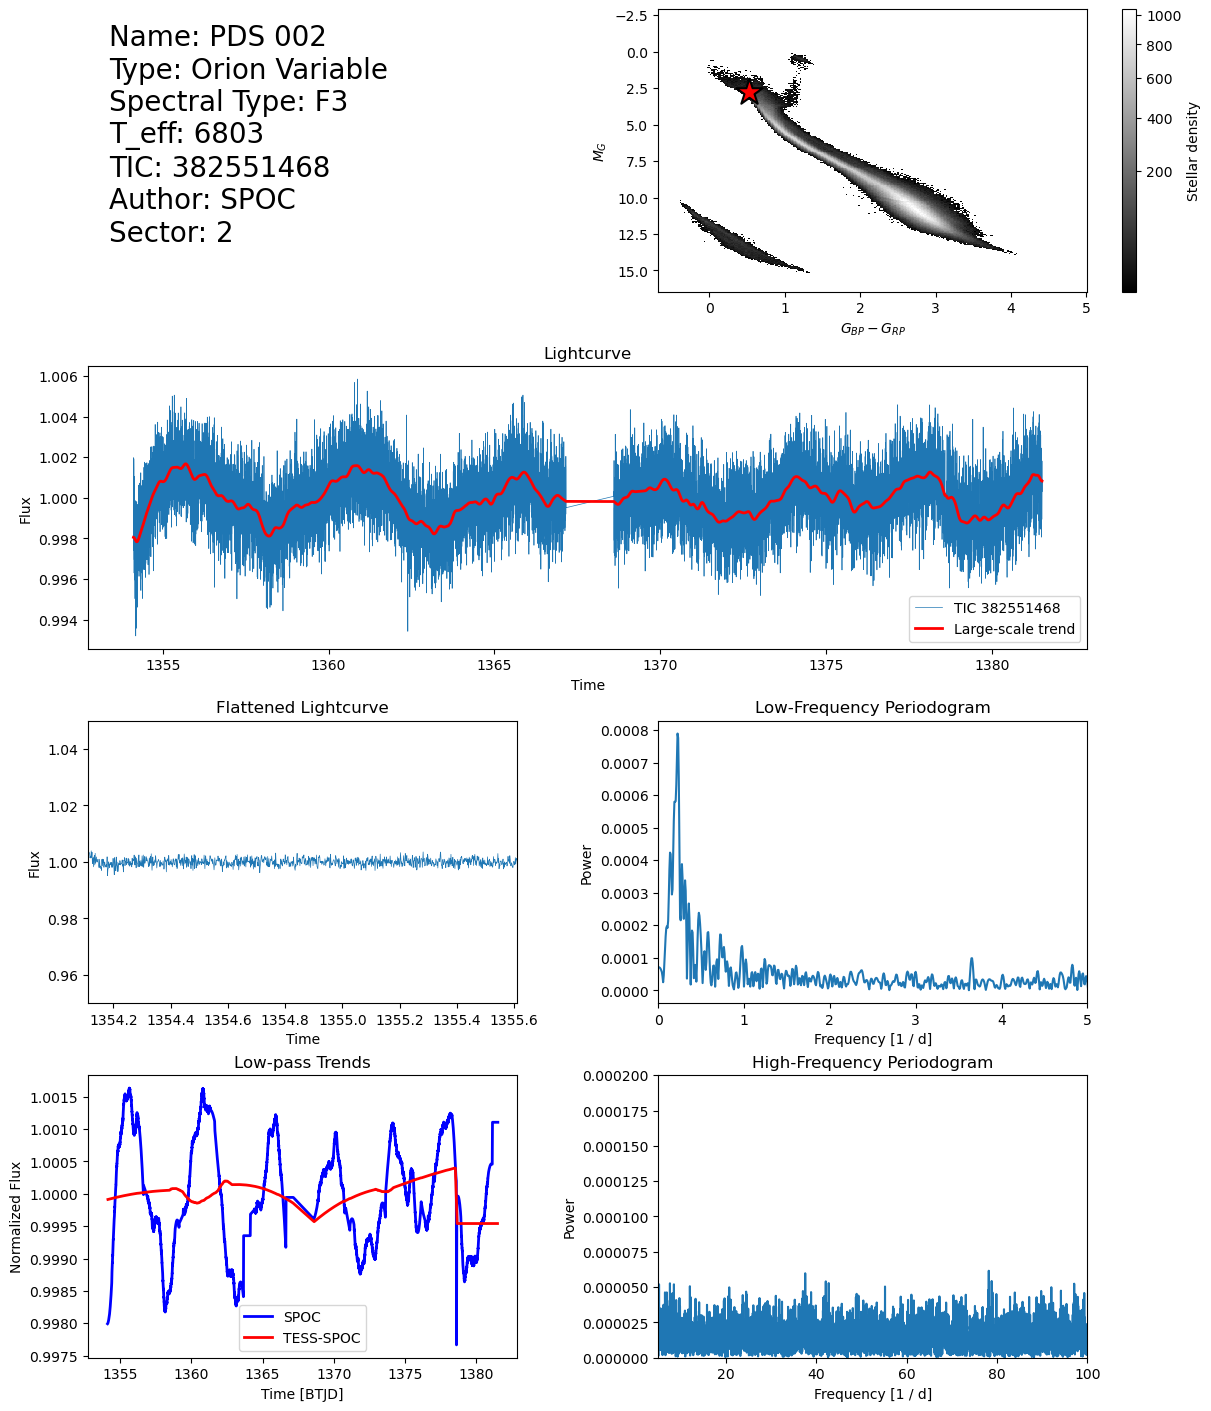

In [83]:
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

fig = plt.figure(layout="constrained", figsize=(12, 14))
axd = fig.subplot_mosaic(
    """
    FG
    AA
    BC
    DE
    """
)

# Information box
axd["F"].axis("off")

info = (
    "Name: HD 344261\n"
    "Type: Star\n"
    "Spectral Type: F2\n"
    "T_eff: 6305\n"
    "TIC: 382551468\n"
    "Author: SPOC\n"
    "Sector: 2\n"
)

axd["F"].text(
    0.05, 0.95,
    info,
    transform=axd["F"].transAxes,
    va="top",
    fontsize=20,
)

# HR Diagram
star_bp_rp = 0.530024
plx = 2.4871
gmag = 10.77784
distance_pc = 1000.0 / plx
star_mg = gmag + 5 - 5*np.log10(distance_pc)

h = axd["G"].hist2d(
    bp_rp,
    mg,
    bins=300,
    cmin=10,
    norm=colors.PowerNorm(0.5),
    cmap="gray",
)
axd["G"].invert_yaxis()
axd["G"].set_xlabel(r"$G_{BP} - G_{RP}$")
axd["G"].set_ylabel(r"$M_G$")

axd["G"].scatter(
    star_bp_rp,
    star_mg,
    marker="*",
    s=400,
    color="red",
    edgecolors="black",
    linewidths=1.5,
    zorder=100,
    label="IM Lup",
)

cbar = fig.colorbar(h[3], ax=axd["G"])
cbar.set_label("Stellar density")

# Lightcurve
sectors = [2]
authors = ["SPOC", "TESS-SPOC"]

lc, pg = utils.get_lightcurve_periodogram(
    "PDS 002",
    author=authors[0],
    sector=sectors[0]
)

t = lc.time.value
f = lc.flux.value

mask = np.isfinite(t) & np.isfinite(f)
t = t[mask]
f = f[mask]

# Sort by time
idx = np.argsort(t)
t = t[idx]
f = f[idx]

# Larger sigma = smoother curve
f_smooth = gaussian_filter1d(f, sigma=50)

# Main light curve / periodogram for panels A, B, C, E
lc_spoc, pg_spoc = utils.get_lightcurve_periodogram(
    "PDS 002",
    author=authors[0],
    sector=sectors[0]
)

lc.plot(ax=axd["A"])
axd["A"].set_xlabel("Time")
axd["A"].set_ylabel("Flux")
axd["A"].set_title("Lightcurve")

axd["A"].plot(
    t,
    f_smooth,
    linewidth=2,
    color="red",
    label="Large-scale trend"
)
axd["A"].legend()

# Flattened lightcurve
time = lc.time.value
flat_lc = lc.flatten(window_length=401)
flat_lc.plot(ax=axd["B"])
axd["B"].set_xlabel("Time")
axd["B"].set_ylabel("Flux")
axd["B"].set_title("Flattened Lightcurve")
axd["B"].set_xlim(time.min(), time.min() + 1.5)
axd["B"].set_ylim(0.95, 1.05)
axd["B"].get_legend().remove()

# Periodogram for low frequency
axd["C"].plot(pg_spoc.frequency.value, pg_spoc.power.value)
axd["C"].set_xlabel(f"Frequency [{pg_spoc.frequency.unit}]")
axd["C"].set_ylabel("Power")
axd["C"].set_xlim(0, 5)
axd["C"].set_title("Low-Frequency Periodogram")

# Flattened lightcurve
sector_colors = {
    "SPOC": "blue",
    "TESS-SPOC": "red",
}

for author in authors:
    lc_author, pg_author = utils.get_lightcurve_periodogram(
        "PDS 002",
        author=author,
        sector=sectors[0]
    )

    lc_author = lc_author.remove_nans().normalize()

    flat_author, trend_author = lc_author.flatten(
        window_length=401,
        return_trend=True
    )

    axd["D"].plot(
        trend_author.time.value,
        trend_author.flux.value,
        linewidth=2,
        color=sector_colors[author],
        label=author
    )

axd["D"].set_xlabel("Time [BTJD]")
axd["D"].set_ylabel("Normalized Flux")
axd["D"].set_title("Low-pass Trends")
axd["D"].legend()

# Periodogram for high frequency
axd["E"].plot(pg_spoc.frequency.value, pg_spoc.power.value)
axd["E"].set_xlabel(f"Frequency [{pg_spoc.frequency.unit}]")
axd["E"].set_ylabel("Power")
axd["E"].set_xlim(5, 100)
axd["E"].set_ylim(0, 0.0002)
axd["E"].set_title("High-Frequency Periodogram")

outdir = Path("figures/Vizier/PDS 002")
outdir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    outdir / "PDS002_sec2_SPOC_summary.png",
    dpi=300,
    bbox_inches="tight"
)

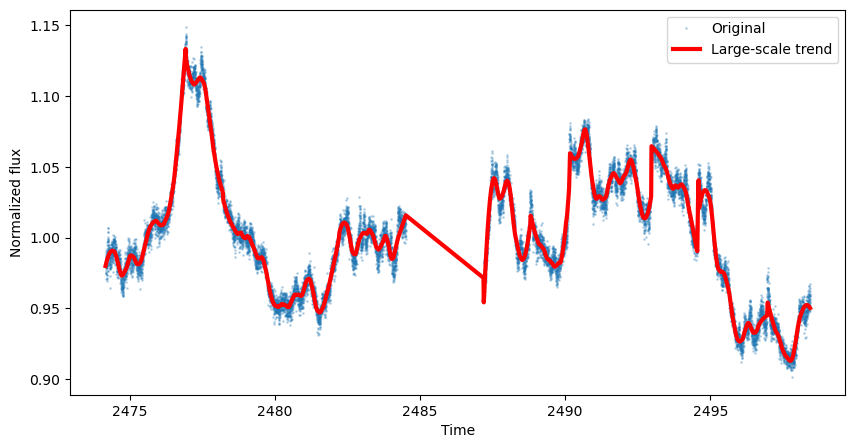

In [70]:
lc = lc.remove_nans().normalize()

flat_lc, trend_lc = lc.flatten(
    window_length=401,
    return_trend=True
)

plt.figure(figsize=(10, 5))

plt.plot(
    lc.time.value,
    lc.flux.value,
    ".",
    alpha=0.25,
    markersize=2,
    label="Original"
)

plt.plot(
    trend_lc.time.value,
    trend_lc.flux.value,
    linewidth=3,
    color="red",
    label="Large-scale trend"
)

plt.xlabel("Time")
plt.ylabel("Normalized flux")
plt.legend()
plt.show()

# Paper plots

In [87]:
import astropy.units as u
from astroquery.vizier import Vizier

v = Vizier(
    columns=["Source", "_r", "Plx", "Gmag", "BPmag", "RPmag", "BP-RP"],
    row_limit=10
)

result = v.query_object(
    "V866 Sco",
    catalog="I/355/gaiadr3",
    radius=2*u.arcmin
)

tab = result[0]
tab.sort("_r")

print(tab)

star = tab[0]
print(star["Source"], star["BP-RP"], star["Plx"], star["Gmag"])

  _r          Source          Plx       Gmag     BPmag     RPmag     BP-RP  
                              mas       mag       mag       mag       mag   
------ ------------------- --------- --------- --------- --------- ---------
1.0576 6245891185879215616        -- 20.714770 21.724894 19.676125  2.048769
1.1972 6245891147223903616    0.5416 19.270676 20.104708 18.363386  1.741322
1.2206 6245891181583640448   -0.5320 19.586030 20.186007 18.877285  1.308722
1.3359 6245891147223901824    0.9021 19.262901 21.101140 18.023256  3.077883
1.5925 6245891151520655872   -0.1410 18.512861 19.112871 17.552614  1.560257
1.6720 6245891151519593728    1.9262 20.516655 21.097832 19.389402  1.708429
1.7607 6245891151520789376    0.7796 15.966038 16.599667 15.181799  1.417868
1.8445 6245891147223900928    0.1200 19.288969 19.886227 18.513050  1.373177
1.8544 6245891151518670208    1.6216 19.893204 20.874489 18.826277  2.048212
1.8687 6245891082799544064    1.4376 20.565441 21.156890 19.636822  1.520069

In [3]:
from astropy.table import Table

url = "https://content.cld.iop.org/journals/0004-637X/994/2/253/revision1/apjae119at2_mrt.txt"

tbl = Table.read(url, format="ascii.mrt")

print(tbl.colnames)

['TIC', 'Sector', 'Phot-ap', 'VType', 'Amp', 'dt', 'Q', 'M']


(4500, 4500)


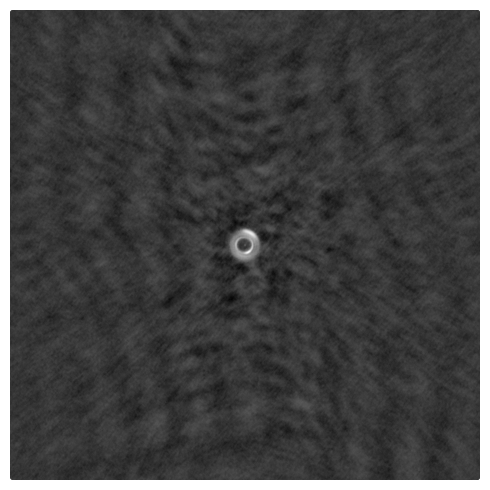

In [19]:
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.visualization import ImageNormalize, AsinhStretch
import numpy as np

img = fits.getdata("Natural_Weighting.fits").squeeze()
print(img.shape)   # should be (4500, 4500)

norm = ImageNormalize(img, stretch=AsinhStretch())

plt.figure(figsize=(5,5))
plt.imshow(img, origin="lower", cmap="gray", norm=norm)
plt.axis("off")
plt.tight_layout()
plt.show()

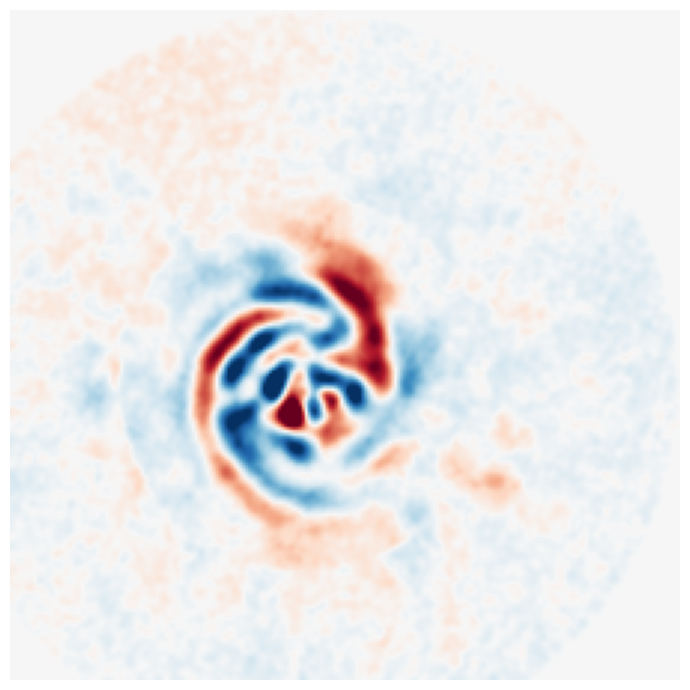

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.ndimage import gaussian_filter

img = fits.getdata("2016_251.fits").squeeze()

# crop center
ny, nx = img.shape
cy, cx = ny//2, nx//2
r = 350
crop = img[cy-r:cy+r, cx-r:cx+r]

# optional: smooth slightly
crop_s = gaussian_filter(crop, sigma=1)

# symmetric contrast around zero
v = np.nanpercentile(np.abs(crop_s), 99.5)

plt.figure(figsize=(7,7))
plt.imshow(
    crop_s,
    origin="lower",
    cmap="RdBu_r",   # good for positive/negative spiral residuals
    vmin=-v,
    vmax=v
)
plt.axis("off")
plt.tight_layout()
plt.show()

In [3]:
from astropy.io import fits

hdul = fits.open("Fig1.fits")
hdul.info()

Filename: Fig1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      79   (4500, 4500, 1, 1)   float32   


In [4]:
for i,hdu in enumerate(hdul):
    print(i, hdu.data.shape if hdu.data is not None else None)

0 (1, 1, 4500, 4500)


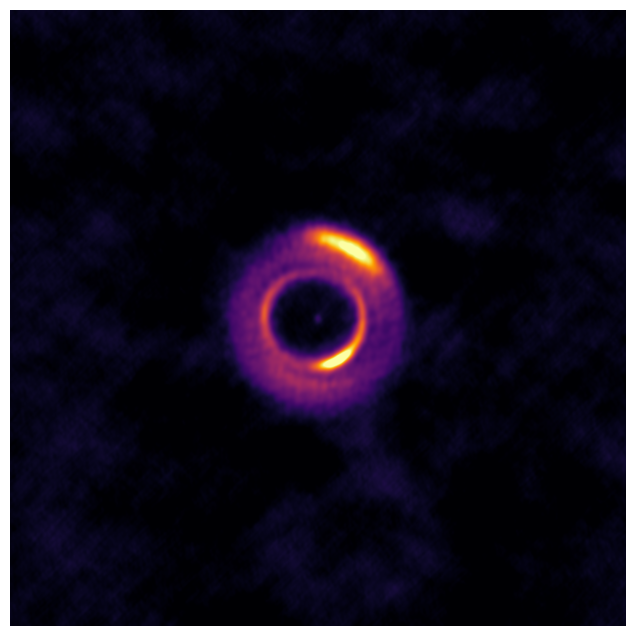

In [20]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from astropy.visualization import ImageNormalize, AsinhStretch

img = fits.getdata("Natural_Weighting.fits").squeeze()

# center of image
ny, nx = img.shape
cx, cy = nx//2, ny//2

# crop size in pixels
r = 500

crop = img[cy-r:cy+r, cx-r:cx+r]

norm = ImageNormalize(
    crop,
    stretch=AsinhStretch(a=0.01)
)

vmin = np.percentile(crop, 20)
vmax = np.percentile(crop, 99.9)

plt.figure(figsize=(8,8))
plt.imshow(
    crop,
    origin="lower",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax
)
plt.axis("off")
plt.show()

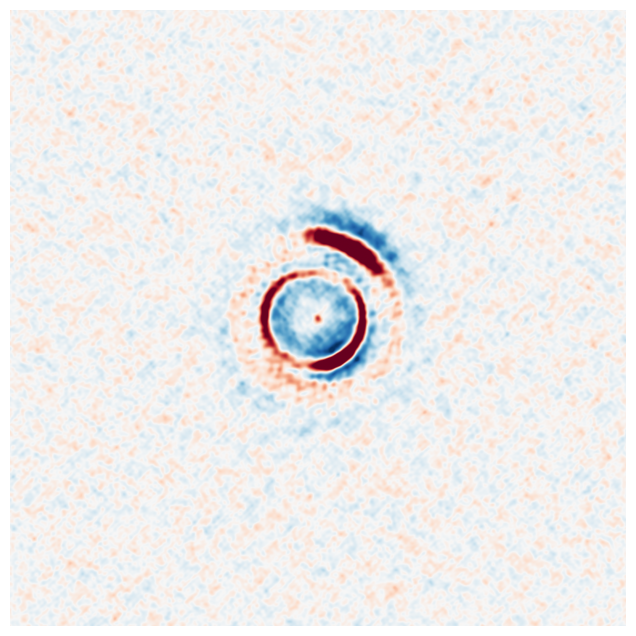

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# smooth model of the disk
smooth = gaussian_filter(crop, sigma=20)

# residual image
resid = crop - smooth

v = np.nanpercentile(np.abs(resid), 99.5)

plt.figure(figsize=(8,8))
plt.imshow(
    resid,
    origin="lower",
    cmap="RdBu_r",
    vmin=-v,
    vmax=v
)
plt.axis("off")
plt.show()

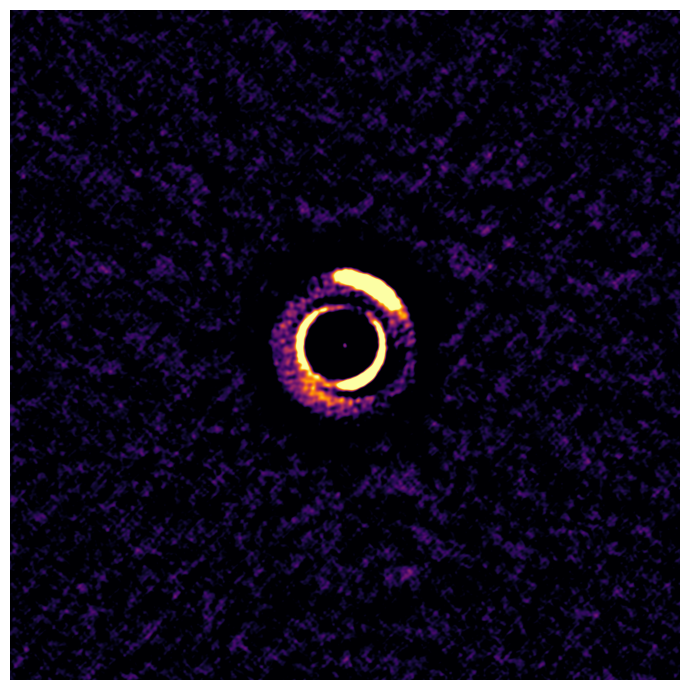

In [15]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

img = fits.getdata("Fig1.fits").squeeze()

ny, nx = img.shape
cy, cx = ny//2, nx//2

# tighter crop; adjust 500 -> 700 if you want wider
r = 650
crop = img[cy-r:cy+r, cx-r:cx+r]

# remove large-scale ring/cavity structure
smooth = gaussian_filter(crop, sigma=35)
resid = crop - smooth

v = np.nanpercentile(np.abs(resid), 99.5)

plt.figure(figsize=(7,7))
plt.imshow(resid, origin="lower", cmap="inferno", vmin=0, vmax=v)
plt.axis("off")
plt.tight_layout()
plt.show()

SearchResult containing 1 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 71 2023   SPOC     120    73816033      0.0


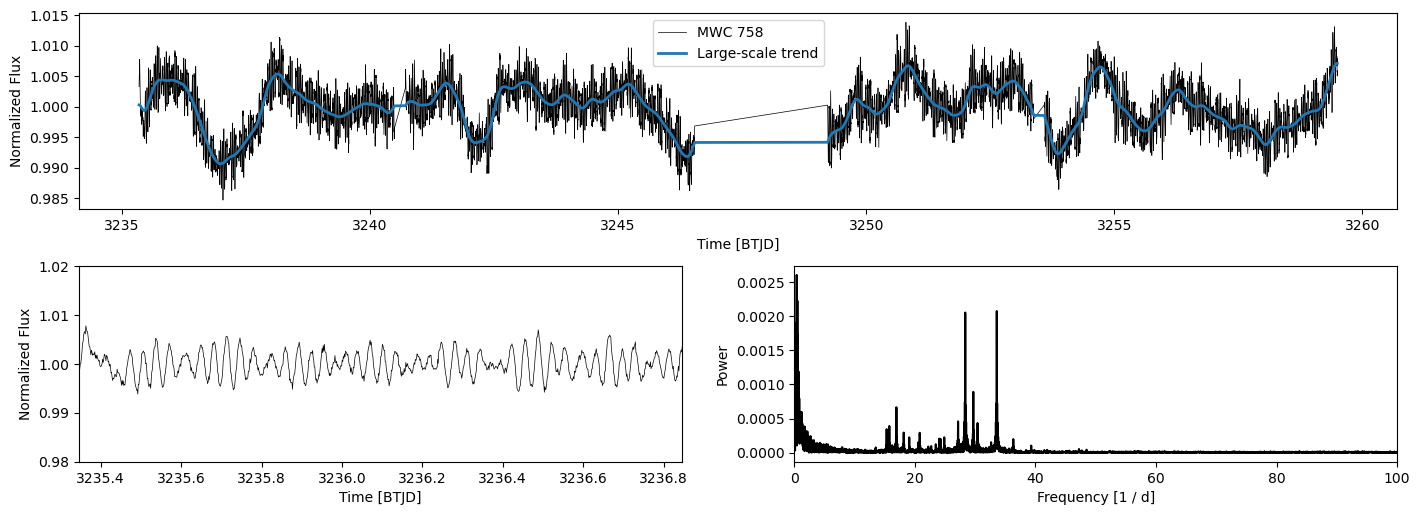

In [45]:
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

fig = plt.figure(layout="constrained", figsize=(14, 5))
axd = fig.subplot_mosaic(
    """
    AA
    BC
    """
)

# Lightcurve
sectors = [71]

lc, pg = utils.get_lightcurve_periodogram(
    "MWC 758",
    author="SPOC",
    sector=sectors[0]
)

t = lc.time.value
f = lc.flux.value

mask = np.isfinite(t) & np.isfinite(f)
t = t[mask]
f = f[mask]

# Sort by time
idx = np.argsort(t)
t = t[idx]
f = f[idx]

# Larger sigma = smoother curve
f_smooth = gaussian_filter1d(f, sigma=50)

star_name = "MWC 758"

lc.plot(
    ax=axd["A"],
    color="black",
    label=star_name
)
axd["A"].set_xlabel("Time [BTJD]")
axd["A"].set_ylabel("Normalized Flux")
#axd["A"].set_title("Lightcurve")

axd["A"].plot(
    t,
    f_smooth,
    linewidth=2,
    color="#1f77b4",
    label="Large-scale trend"
)
axd["A"].legend()

# Flattened lightcurve
time = lc.time.value
flat_lc = lc.flatten(window_length=401)
flat_lc.plot(ax=axd["B"], color="black")
axd["B"].set_xlabel("Time [BTJD]")
axd["B"].set_ylabel("Normalized Flux")
#axd["B"].set_title("Flattened Lightcurve")
axd["B"].set_xlim(time.min(), time.min() + 1.5)
axd["B"].set_ylim(0.98, 1.02)
axd["B"].get_legend().remove()

# Periodogram for low frequency
axd["C"].plot(pg.frequency.value, pg.power.value, color="black")
axd["C"].set_xlabel(f"Frequency [{pg.frequency.unit}]")
axd["C"].set_ylabel("Power")
axd["C"].set_xlim(0, 100)
#axd["C"].set_ylim(0, 0.0003)
#axd["C"].set_title("Low-Frequency Periodogram")

outdir = Path("figures/")
outdir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    outdir / "MWC758_paperplot.png",
    dpi=300,
    bbox_inches="tight"
)